# Model Pipeline - Fashion Forward Forecasting

This notebook demonstrates the complete ML pipeline for predicting product recommendations based on customer reviews.

**Features:**
- Data loading and preprocessing
- Feature engineering with text, numeric, and categorical data
- Model training with hyperparameter tuning (RandomizedSearchCV)
- Model evaluation and metrics
- Model persistence and inference

## 1. Setup and Imports

In [1]:
import sys
import os

# Add src to path for importing our modules
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), 'src'))
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Import our custom modules
from src.data_processing import load_data, split_data, create_sample_data
from src.features import build_preprocessor
from src.model import build_model_pipeline, train_pipeline

print("All imports successful!")

All imports successful!


## 2. Create and Load Sample Data

We'll use the included sample dataset to demonstrate the pipeline. For production use, replace with the full dataset.

In [2]:
# Create sample data (if not already exists)
sample_path = '../data/raw/reviews_sample.csv'
create_sample_data(sample_path)
print(f"Sample data created at: {sample_path}")

# Load the data
df = load_data(sample_path)
print(f"\nLoaded {len(df)} samples")
print(f"\nColumns: {list(df.columns)}")
df.head()

Sample data created at: ../data/raw/reviews_sample.csv

Loaded 15 samples

Columns: ['review_text', 'age', 'product_category', 'recommended']


,review_text,age,product_category,recommended
0,Absolutely love this dress! The fit is perfect...,34,Dresses,1
1,Not worth the price. The material feels cheap ...,45,Tops,0
2,This top is cute but runs a bit large. I shoul...,28,Tops,1
3,Perfect for summer! Lightweight and comfortabl...,52,Dresses,1
4,The stitching came undone after one wash. Poor...,31,Blouses,0


In [3]:
# Explore the data
print("Data Info:")
print(df.info())
print("\nTarget distribution:")
print(df['recommended'].value_counts())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       15 non-null     object
 1   age               15 non-null     int64 
 2   product_category  15 non-null     object
 3   recommended       15 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 612.0+ bytes
None

Target distribution:
recommended
1    11
0     4
Name: count, dtype: int64


## 3. Split Data into Train/Test Sets

In [4]:
# Split the data
X_train, X_test, y_train, y_test = split_data(
    df, 
    target_col='recommended',
    test_size=0.2,
    random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())

Training set size: 12
Test set size: 3

Training target distribution:
recommended
1    9
0    3
Name: count, dtype: int64


## 4. Build the Preprocessor and Model Pipeline

The preprocessor handles:
- **Numeric features**: Imputation with median, then standardization
- **Categorical features**: Imputation with constant, then one-hot encoding
- **Text features**: Cleaning, then TF-IDF vectorization

In [5]:
# Define feature columns
numeric_cols = ['age']
categorical_cols = ['product_category']
text_col = 'review_text'

# Build preprocessor
preprocessor = build_preprocessor(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    text_col=text_col
)

# Build the complete pipeline
pipeline = build_model_pipeline(preprocessor)

print("Pipeline structure:")
print(pipeline)

Pipeline structure:
Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneH

## 5. Train with Hyperparameter Tuning

We use `RandomizedSearchCV` with `StratifiedKFold` cross-validation to find optimal hyperparameters.

**Note:** For this interactive demo, we use `n_iter=10` for fast execution. For production training, increase to `n_iter=50` or more.

In [6]:
# Define hyperparameter search space
param_distributions = {
    # TF-IDF parameters
    'preproc__txt__tfidf__max_features': [500, 1000, 2000],
    'preproc__txt__tfidf__ngram_range': [(1, 1), (1, 2)],
    # Classifier parameters  
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs', 'saga'],
}

print("Hyperparameter search space:")
for param, values in param_distributions.items():
    print(f"  {param}: {values}")

Hyperparameter search space:
  preproc__txt__tfidf__max_features: [500, 1000, 2000]
  preproc__txt__tfidf__ngram_range: [(1, 1), (1, 2)]
  clf__C: [0.01, 0.1, 1, 10]
  clf__penalty: ['l2']
  clf__solver: ['lbfgs', 'saga']


In [7]:
# Train with RandomizedSearchCV
# Using n_iter=10 and cv=3 for quick interactive demo
# For production, use n_iter=50 and cv=5

search = train_pipeline(
    pipeline=pipeline,
    X_train=X_train,
    y_train=y_train,
    param_distributions=param_distributions,
    n_iter=10,  # Reduced for interactive demo
    cv=3,       # Reduced for small sample size
    scoring='f1',
    random_state=42,
    save_path='../models/model_v1.joblib',
    verbose=1
)

print("\nTraining complete!")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best model saved to: ../models/model_v1.joblib

Training complete!


In [8]:
# Display best parameters and score
print("Best Parameters:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest Cross-Validation F1 Score: {search.best_score_:.4f}")

Best Parameters:
  preproc__txt__tfidf__ngram_range: (1, 2)
  preproc__txt__tfidf__max_features: 1000
  clf__solver: lbfgs
  clf__penalty: l2
  clf__C: 1

Best Cross-Validation F1 Score: 0.8571


## 6. Evaluate on Test Set

In [9]:
# Get the best model
best_model = search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba) if len(np.unique(y_test)) > 1 else 0.0
}

print("Test Set Metrics:")
print("=" * 40)
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Test Set Metrics:
Accuracy: 0.6667
Precision: 0.6667
Recall: 1.0000
F1 Score: 0.8000
ROC-AUC: 0.0000


In [10]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



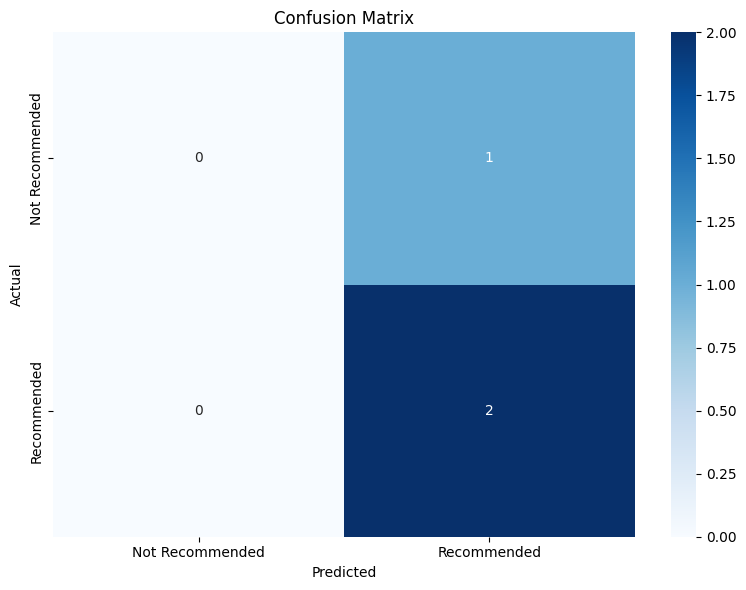

In [11]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Recommended', 'Recommended'],
            yticklabels=['Not Recommended', 'Recommended'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 7. Load Saved Model and Run Inference

In [12]:
# Load the saved model
loaded_model = joblib.load('../models/model_v1.joblib')
print("Model loaded successfully!")
print(f"Model type: {type(loaded_model).__name__}")

Model loaded successfully!
Model type: Pipeline


In [13]:
# Create a sample row for inference
sample_input = pd.DataFrame({
    'review_text': ["This product is amazing! I absolutely love it and would recommend to everyone."],
    'age': [35],
    'product_category': ['Dresses']
})

print("Sample input:")
print(sample_input)

# Make prediction
prediction = loaded_model.predict(sample_input)
prediction_proba = loaded_model.predict_proba(sample_input)

print(f"\nPrediction: {'Recommended' if prediction[0] == 1 else 'Not Recommended'}")
print(f"Confidence: {prediction_proba[0][prediction[0]]:.2%}")

Sample input:
                                         review_text  age product_category
0  This product is amazing! I absolutely love it ...   35          Dresses

Prediction: Recommended
Confidence: 72.91%


In [14]:
# Test with a negative review
negative_sample = pd.DataFrame({
    'review_text': ["Terrible quality. The product fell apart after one use. Very disappointed."],
    'age': [42],
    'product_category': ['Tops']
})

print("Negative sample input:")
print(negative_sample)

prediction = loaded_model.predict(negative_sample)
prediction_proba = loaded_model.predict_proba(negative_sample)

print(f"\nPrediction: {'Recommended' if prediction[0] == 1 else 'Not Recommended'}")
print(f"Confidence: {prediction_proba[0][prediction[0]]:.2%}")

Negative sample input:
                                         review_text  age product_category
0  Terrible quality. The product fell apart after...   42             Tops

Prediction: Recommended
Confidence: 75.39%


## 8. Summary

This notebook demonstrated:
1. Loading and exploring the sample dataset
2. Building a preprocessing pipeline for mixed data types
3. Training a model with hyperparameter tuning using RandomizedSearchCV
4. Evaluating model performance on a holdout test set
5. Saving and loading the trained model
6. Running inference on new samples

**Next Steps:**
- Use the full dataset for production training
- Increase `n_iter` for more thorough hyperparameter search
- Experiment with different classifiers (e.g., RandomForest, GradientBoosting)
- Add more sophisticated text features (e.g., word embeddings)